In [5]:
%pip install smogn

  Using cached smogn-0.1.2-py3-none-any.whl.metadata (4.5 kB)
Using cached smogn-0.1.2-py3-none-any.whl (30 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import smogn as sm

In [9]:

# 1. Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [10]:
data = pd.read_csv("comprehensive_strength.csv")

In [11]:
data

,RUN,CNTs,RA,water,SP,Comp Strength 1 (N/mm2)
0,1.0,0.002,3.277,1.435,0.045,17.000000
1,2.0,0.003,0.936,1.435,0.015,21.444444
2,3.0,0.003,3.277,1.435,0.030,18.400000
3,4.0,0.002,3.277,1.662,0.030,18.311111
4,5.0,0.003,3.277,1.662,0.015,20.444444
5,6.0,0.003,5.618,1.209,0.030,23.555556
6,7.0,0.005,5.618,1.435,0.030,19.111111
7,8.0,0.005,0.936,1.435,0.030,15.688889
8,9.0,0.003,0.936,1.662,0.030,11.622222
9,10.0,0.002,0.936,1.435,0.030,10.977778


In [12]:
data.drop(27, axis = 0, inplace = True)

In [13]:
data

,RUN,CNTs,RA,water,SP,Comp Strength 1 (N/mm2)
0,1.0,0.002,3.277,1.435,0.045,17.000000
1,2.0,0.003,0.936,1.435,0.015,21.444444
2,3.0,0.003,3.277,1.435,0.030,18.400000
3,4.0,0.002,3.277,1.662,0.030,18.311111
4,5.0,0.003,3.277,1.662,0.015,20.444444
5,6.0,0.003,5.618,1.209,0.030,23.555556
6,7.0,0.005,5.618,1.435,0.030,19.111111
7,8.0,0.005,0.936,1.435,0.030,15.688889
8,9.0,0.003,0.936,1.662,0.030,11.622222
9,10.0,0.002,0.936,1.435,0.030,10.977778


## 3. Exploratory Data Analysis (EDA)

* CNT => Carbon Nano tube in Kg
* RA => Recycled Aggregate in Kg
* GA => Gum Arabic in kg

In [14]:

data.describe().round(3)


,RUN,CNTs,RA,water,SP,Comp Strength 1 (N/mm2)
count,27.000,27.000,27.000,27.000,27.000,27.000
mean,14.000,0.003,3.277,1.435,0.030,16.198
std,7.937,0.001,1.590,0.154,0.010,3.953
min,1.000,0.002,0.936,1.209,0.015,9.867
25%,7.500,0.003,3.277,1.435,0.030,12.933
50%,14.000,0.003,3.277,1.435,0.030,15.911
75%,20.500,0.003,3.277,1.435,0.030,18.756
max,27.000,0.005,5.618,1.662,0.045,23.556


In [19]:
data.rename(columns={"CNTs": "CNT_kg",
                     "RA": "RCA_kg",
                     "water": "Water_kg",
                     "SP": "Gum_Arabic_kg",
                     "Comp Strength 1 (N/mm2) ": "compressive_strength_N/mm2"}, inplace = True)

In [16]:
data.head(2)

,RUN,CNT_kg,RCA_kg,water,Gum_Arabic_kg,compressive_strength_N/mm2
0,1.0,0.002,3.277,1.435,0.045,17.000000
1,2.0,0.003,0.936,1.435,0.015,21.444444


In [17]:
data.drop("RUN", axis = 1, inplace=True)

In [20]:
data = data.sort_values("Water_kg", ascending=False)
data

,CNT_kg,RCA_kg,Water_kg,Gum_Arabic_kg,compressive_strength_N/mm2
3,0.002,3.277,1.662,0.030,18.311111
4,0.003,3.277,1.662,0.015,20.444444
22,0.005,3.277,1.662,0.030,9.866667
20,0.003,5.618,1.662,0.030,15.911111
8,0.003,0.936,1.662,0.030,11.622222
19,0.003,3.277,1.662,0.045,13.333333
0,0.002,3.277,1.435,0.045,17.000000
1,0.003,0.936,1.435,0.015,21.444444
24,0.003,3.277,1.435,0.030,14.266667
21,0.003,0.936,1.435,0.045,16.088889


In [27]:
rng = np.random.default_rng(42)

def jitter_augment(df, feature_cols, target_col, n_per_row=4, noise_pct=0.02):
    rows = []
    for _, row in df.iterrows():
        for _ in range(n_per_row):
            new_row = row.copy()
            for col in feature_cols:
                new_row[col] *= rng.normal(1, noise_pct)
            new_row[target_col] *= rng.normal(1, noise_pct)
            rows.append(new_row)
    return pd.DataFrame(rows)

augmented = jitter_augment(data, feature_cols=["CNT_kg","RCA_kg","Water_kg","Gum_Arabic_kg"],
                            target_col="compressive_strength_N/mm2", n_per_row=4, noise_pct=0.02)
train_augmented = pd.concat([data, augmented], ignore_index=True)

In [28]:
train_augmented.shape

(135, 5)

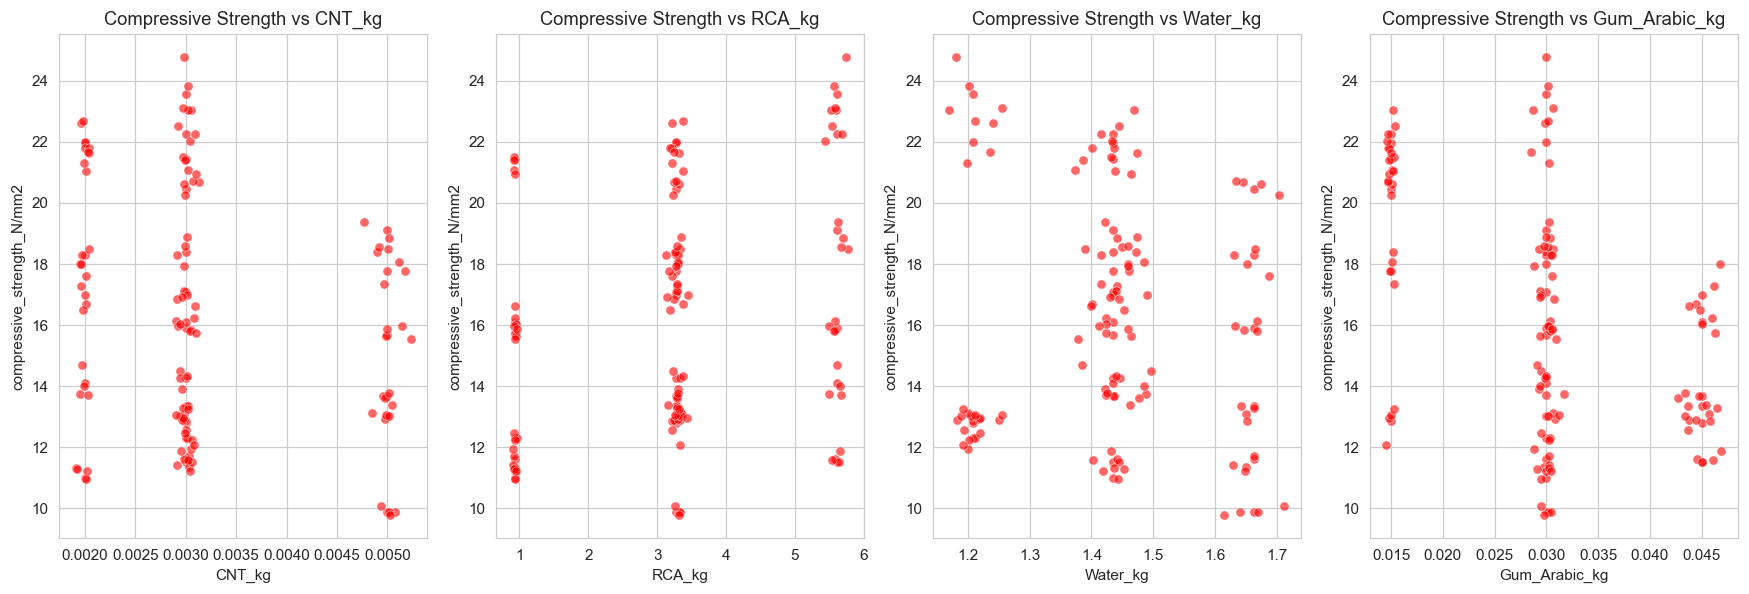

In [29]:

fig, axes = plt.subplots(1, 4, figsize=(16, 5.5))
for ax, col in zip(axes, ["CNT_kg", "RCA_kg", "Water_kg", "Gum_Arabic_kg"]):
    sns.scatterplot(data=train_augmented, x=col, y="compressive_strength_N/mm2", ax=ax, alpha=0.6, color = "red" )
    ax.set_title(f"Compressive Strength vs {col}")
plt.tight_layout()
plt.savefig("eda_scatter.png")
plt.show()


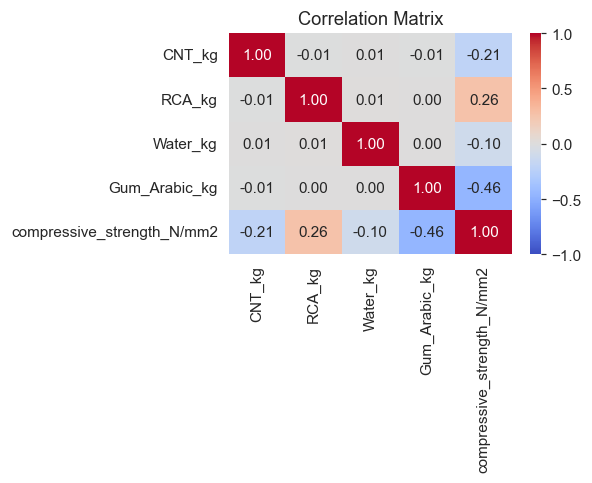

In [30]:

plt.figure(figsize=(5.5, 4.5))
corr = train_augmented.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("eda_corr.png")
plt.show()


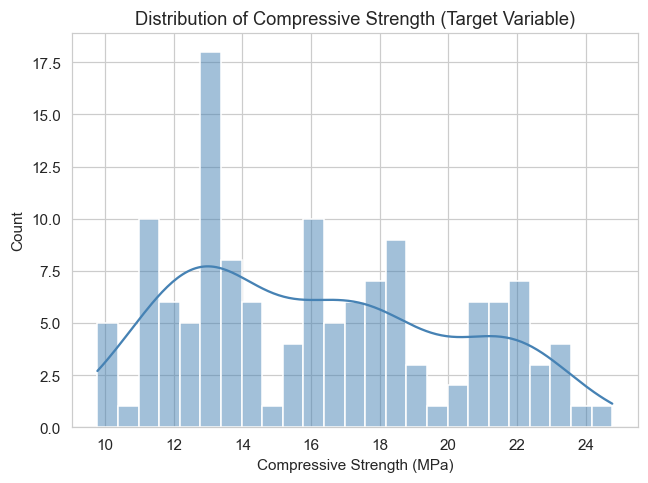

In [31]:

plt.figure(figsize=(6, 4.5))
sns.histplot(train_augmented["compressive_strength_N/mm2"], kde=True, bins=25, color="steelblue")
plt.title("Distribution of Compressive Strength (Target Variable)")
plt.xlabel("Compressive Strength (MPa)")
plt.tight_layout()
plt.savefig("eda_target_dist.png")
plt.show()


## 4. Train / Validation / Test Split (70 / 15 / 15)

In [32]:

X = train_augmented[["CNT_kg", "RCA_kg", "Water_kg", "Gum_Arabic_kg"]]
y = train_augmented["compressive_strength_N/mm2"]

# First split off the test set (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE
)

# Then split remaining 85% into train (70% of total) and validation (15% of total)
val_fraction_of_temp = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_fraction_of_temp, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]} samples ({X_train.shape[0]/len(X):.1%})")
print(f"Validation: {X_val.shape[0]} samples ({X_val.shape[0]/len(X):.1%})")
print(f"Test: {X_test.shape[0]} samples ({X_test.shape[0]/len(X):.1%})")


Train: 93 samples (68.9%)
Validation: 21 samples (15.6%)
Test: 21 samples (15.6%)



## 5. Modeling — Pipelines for Scaling + Fitting

Each model is wrapped in an `sklearn.pipeline.Pipeline` so that **scaling and model fitting travel together as one object**. This means:

- No risk of forgetting to scale new data the same way before prediction.
- The whole pipeline (scaler + trained model) can be saved with `joblib.dump()` and reloaded later with `joblib.load()` — ready to predict directly on raw `CNT_pct, RCA_pct, wc_ratio` inputs.

We build three ML models — matching Section 3.2/3.3.8 exactly:
1. **Artificial Neural Network** → `MLPRegressor`
2. **Random Forest** → `RandomForestRegressor`
3. **Support Vector Machine (regression)** → `SVR`

Random Forest and SVR are sensitive to feature scale (SVR especially); scaling is harmless for Random Forest but included for pipeline consistency.

Hyperparameters are tuned with `GridSearchCV` (5-fold CV) on the training set only; the validation set is then used as an independent check before final testing.


In [33]:
models = {"random forest": RandomForestRegressor(),
          }

In [34]:
# 5.1 Random Forest pipeline
rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE))
])

rf_param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 6, 10],
    "model__min_samples_leaf": [1, 2, 4],
}

rf_grid = GridSearchCV(
    rf_pipeline, rf_param_grid, cv=5,
    scoring="r2", n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print("Best RF params:", rf_grid.best_params_)
print(f"Best RF CV R²: {rf_grid.best_score_:.4f}")

rf_best = rf_grid.best_estimator_


Best RF params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 400}
Best RF CV R²: 0.4786


In [35]:

# 5.2 Support Vector Regression pipeline
svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR())
])

svr_param_grid = {
    "model__kernel": ["rbf"],
    "model__C": [1, 10, 50, 100],
    "model__epsilon": [0.1, 0.5, 1],
    "model__gamma": ["scale", "auto"],
}

svr_grid = GridSearchCV(
    svr_pipeline, svr_param_grid, cv=5,
    scoring="r2", n_jobs=-1
)
svr_grid.fit(X_train, y_train)

print("Best SVR params:", svr_grid.best_params_)
print(f"Best SVR CV R²: {svr_grid.best_score_:.4f}")

svr_best = svr_grid.best_estimator_


Best SVR params: {'model__C': 50, 'model__epsilon': 0.1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best SVR CV R²: 0.9445


In [36]:

# 5.3 Artificial Neural Network (MLP) pipeline
ann_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(max_iter=5000, random_state=RANDOM_STATE, early_stopping=True))
])

ann_param_grid = {
    "model__hidden_layer_sizes": [(16,), (32,), (32, 16), (64, 32)],
    "model__activation": ["relu", "tanh"],
    "model__alpha": [0.0001, 0.001, 0.01],
    "model__learning_rate_init": [0.001, 0.01],
}

ann_grid = GridSearchCV(
    ann_pipeline, ann_param_grid, cv=5,
    scoring="r2", n_jobs=-1
)
ann_grid.fit(X_train, y_train)

print("Best ANN params:", ann_grid.best_params_)
print(f"Best ANN CV R²: {ann_grid.best_score_:.4f}")

ann_best = ann_grid.best_estimator_


Best ANN params: {'model__activation': 'relu', 'model__alpha': 0.01, 'model__hidden_layer_sizes': (64, 32), 'model__learning_rate_init': 0.001}
Best ANN CV R²: 0.7521


In [37]:

rsm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", LinearRegression())
])

rsm_pipeline.fit(X_train, y_train)
print("RSM (quadratic regression) pipeline fitted.")


RSM (quadratic regression) pipeline fitted.


## 7. Model Evaluation

In [38]:

def evaluate(model, X, y, label):
    preds = model.predict(X)
    r2 = r2_score(y, preds)
    rmse = np.sqrt(mean_squared_error(y, preds))
    mae = mean_absolute_error(y, preds)
    return {"Model": label, "R2": r2, "RMSE": rmse, "MAE": mae}

models = {
    "Random Forest": rf_best,
    "SVR": svr_best,
    "ANN (MLP)": ann_best,
    "RSM (Quadratic)": rsm_pipeline,
}

results_val = pd.DataFrame([evaluate(m, X_val, y_val, name) for name, m in models.items()])
results_test = pd.DataFrame([evaluate(m, X_test, y_test, name) for name, m in models.items()])

print("Validation set performance:")
display(results_val.sort_values("R2", ascending=False).reset_index(drop=True))

print("\nTest set performance:")
display(results_test.sort_values("R2", ascending=False).reset_index(drop=True))


Validation set performance:


,Model,R2,RMSE,MAE
0,SVR,0.956189,0.909557,0.556305
1,Random Forest,0.746995,2.185762,1.649134
2,RSM (Quadratic),0.243293,3.780087,3.184599
3,ANN (MLP),0.137248,4.036276,3.487687



Test set performance:


,Model,R2,RMSE,MAE
0,SVR,0.925442,0.936089,0.646167
1,Random Forest,0.544016,2.314974,1.746101
2,RSM (Quadratic),0.196263,3.073465,2.592616
3,ANN (MLP),-0.221216,3.788501,3.154647


C:\Users\Admin\AppData\Local\Temp\ipykernel_8452\432147688.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_test.sort_values("R2", ascending=False),
C:\Users\Admin\AppData\Local\Temp\ipykernel_8452\432147688.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_test.sort_values("R2", ascending=False),
C:\Users\Admin\AppData\Local\Temp\ipykernel_8452\432147688.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_test.sort_values("R2", ascending=False),


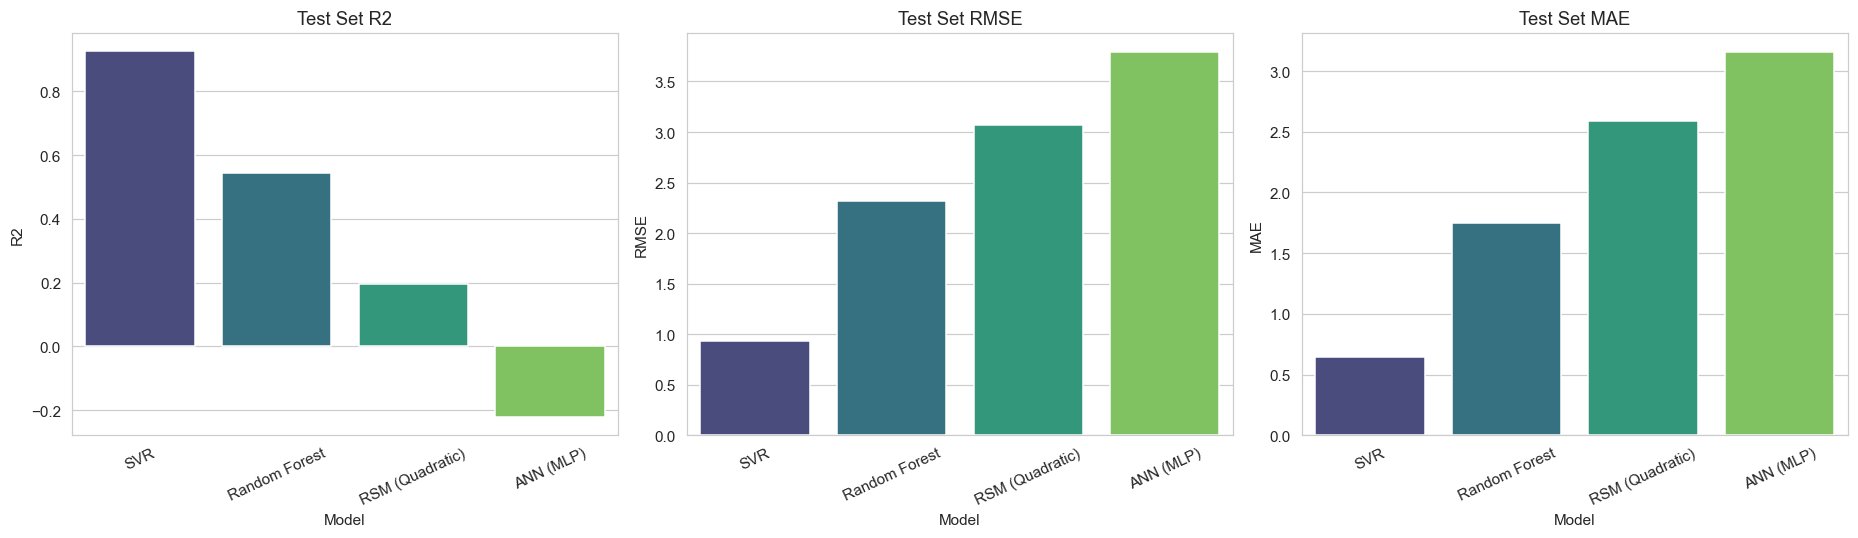

In [39]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
metrics = ["R2", "RMSE", "MAE"]
for ax, metric in zip(axes, metrics):
    sns.barplot(data=results_test.sort_values("R2", ascending=False),
                x="Model", y=metric, ax=ax, palette="viridis")
    ax.set_title(f"Test Set {metric}")
    ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.savefig("model_comparison.png")
plt.show()


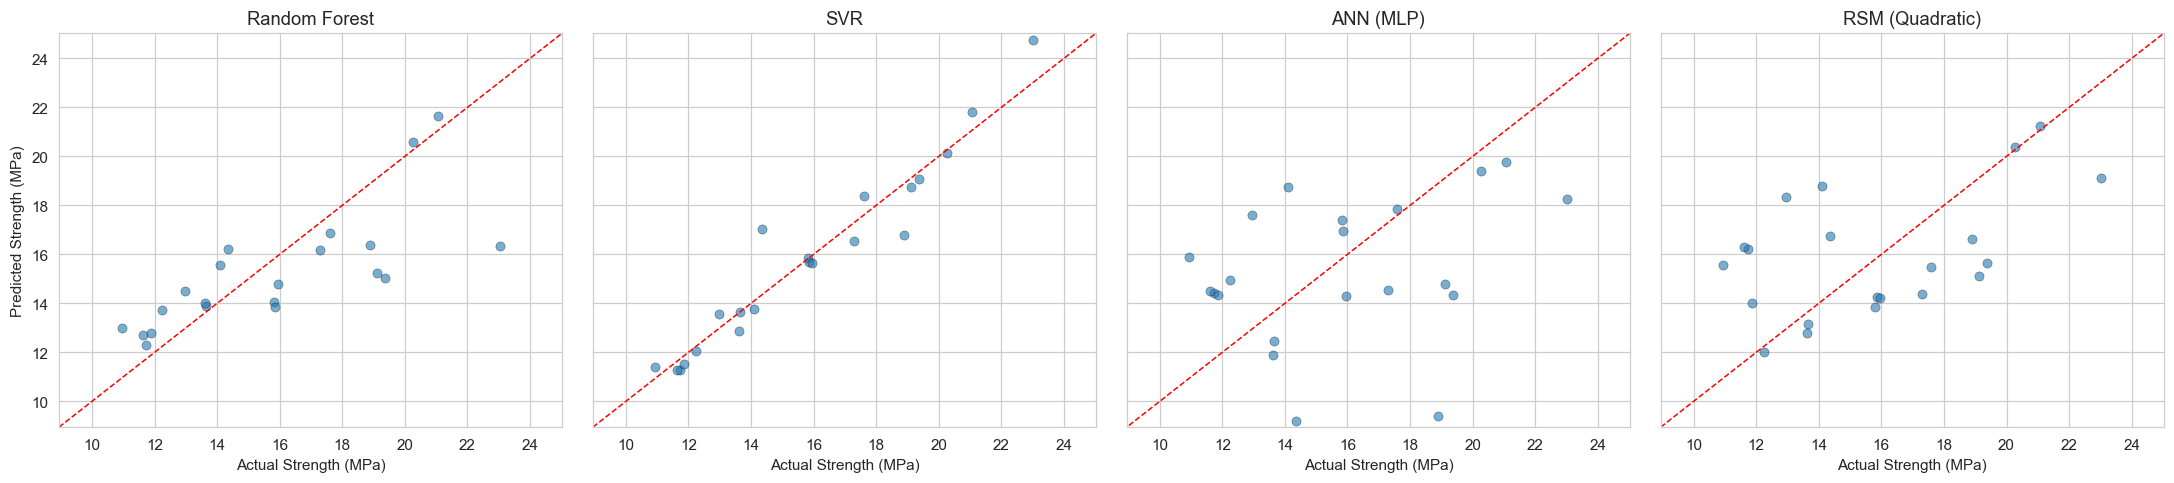

In [40]:

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharex=True, sharey=True)
for ax, (name, model) in zip(axes, models.items()):
    preds = model.predict(X_test)
    ax.scatter(y_test, preds, alpha=0.6, edgecolor="k", linewidth=0.3)
    lims = [min(y_test.min(), preds.min()) - 2, max(y_test.max(), preds.max()) + 2]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_title(name)
    ax.set_xlabel("Actual Strength (MPa)")
axes[0].set_ylabel("Predicted Strength (MPa)")
plt.tight_layout()
plt.savefig("predicted_vs_actual.png")
plt.show()



**Reading the results:**
- The **R² closest to 1**, and **RMSE/MAE closest to 0**, indicate the best-performing model on unseen (test) data.
- The parity plots (predicted vs. actual) show how tightly each model's predictions hug the 45° line — tighter clustering along the diagonal means better predictive accuracy.
- With real experimental data, expect Random Forest and ANN to generally outperform the quadratic RSM model on nonlinear interactions (like the CNT plateau effect), while RSM remains valuable for its interpretable closed-form equation and direct optimization contour/3D response surfaces in Design-Expert.


## 8. Feature Importance (Random Forest)

C:\Users\Admin\AppData\Local\Temp\ipykernel_8452\1294091868.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df, x="Importance", y="Feature", palette="mako")


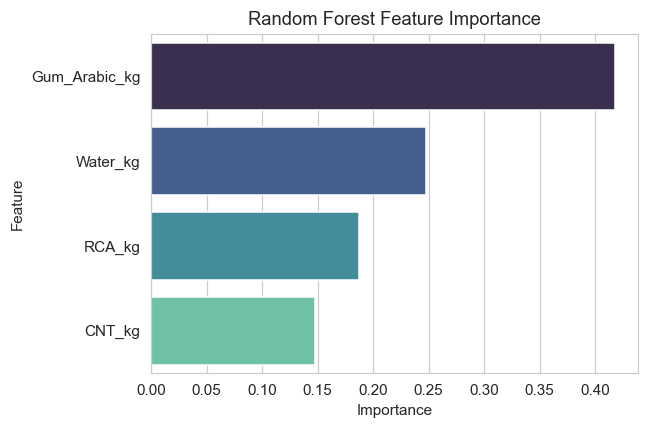

,Feature,Importance
3,Gum_Arabic_kg,0.417809
2,Water_kg,0.247706
1,RCA_kg,0.186944
0,CNT_kg,0.147541


In [41]:

importances = rf_best.named_steps["model"].feature_importances_
feat_names = X.columns

imp_df = pd.DataFrame({"Feature": feat_names, "Importance": importances}).sort_values(
    "Importance", ascending=False
)

plt.figure(figsize=(6, 4))
sns.barplot(data=imp_df, x="Importance", y="Feature", palette="mako")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

imp_df



## 9. Selecting and Saving the Best Model



In [42]:

best_row = results_test.sort_values("R2", ascending=False).iloc[0]
best_model_name = best_row["Model"]
best_model = models[best_model_name]

print(f"Best performing model on test set: {best_model_name}")
print(best_row)

joblib.dump(best_model, "best_compressive_strength_model.joblib")
print("\nSaved pipeline to: best_compressive_strength_model.joblib")

# Also save all four pipelines individually, in case you want to compare/deploy any of them
joblib.dump(rf_best, "model_random_forest.joblib")
joblib.dump(svr_best, "model_svr.joblib")
joblib.dump(ann_best, "model_ann.joblib")
joblib.dump(rsm_pipeline, "model_rsm_quadratic.joblib")
print("Saved individual pipelines: model_random_forest.joblib, model_svr.joblib, model_ann.joblib, model_rsm_quadratic.joblib")


Best performing model on test set: SVR
Model         SVR
R2       0.925442
RMSE     0.936089
MAE      0.646167
Name: 1, dtype: object

Saved pipeline to: best_compressive_strength_model.joblib
Saved individual pipelines: model_random_forest.joblib, model_svr.joblib, model_ann.joblib, model_rsm_quadratic.joblib


## 10. Example: Loading the Saved Model and Predicting on New Mix Designs

In [43]:

# Simulate "loading the model fresh" as you would in a new session/deployment
loaded_model = joblib.load("best_compressive_strength_model.joblib")

# Example new candidate mixes to evaluate
new_mixes = pd.DataFrame({
    "CNT_kg":  [0.00, 0.15, 0.20, 0.30],
    "RCA_kg":  [0,    50,   30,   100],
    "Water_kg": [0.45, 0.45, 0.40, 0.55],
    "Gum_Arabic_kg": [0.99, 0.28, 0.21, 0.09]
})

new_mixes["Predicted_Strength_MPa"] = loaded_model.predict(new_mixes[["CNT_kg", "RCA_kg", "Water_kg", "Gum_Arabic_kg"]])
new_mixes.round(3)


,CNT_kg,RCA_kg,Water_kg,Gum_Arabic_kg,Predicted_Strength_MPa
0,0.00,0,0.45,0.99,16.733
1,0.15,50,0.45,0.28,16.733
2,0.20,30,0.40,0.21,16.733
3,0.30,100,0.55,0.09,16.733
